# Drug Response classification using SVM

# Task 1 Exploratory Data Analysis(EDA)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load the dataset
df = pd.read_csv("/content/Pharma_Industry.csv")

In [8]:
print("data_set_shape:",df.shape)
display("\n",df.head())
print("\n\n\n Dataset info:",)
df.info()

data_set_shape: (500, 6)


'\n'

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1





 Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [9]:
print("\n Summary Statistics:")
display(df.describe())


 Summary Statistics:


,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [11]:
# understand feature distribution using Histograms & Boxplots
features = ["Drug Dosage (mg)",	"Systolic Blood Pressure (mmHg)",	"Heart Rate (BPM)",	"Liver Toxicity Index (U/L)",	"Blood Glucose Level (mg/dL)"]


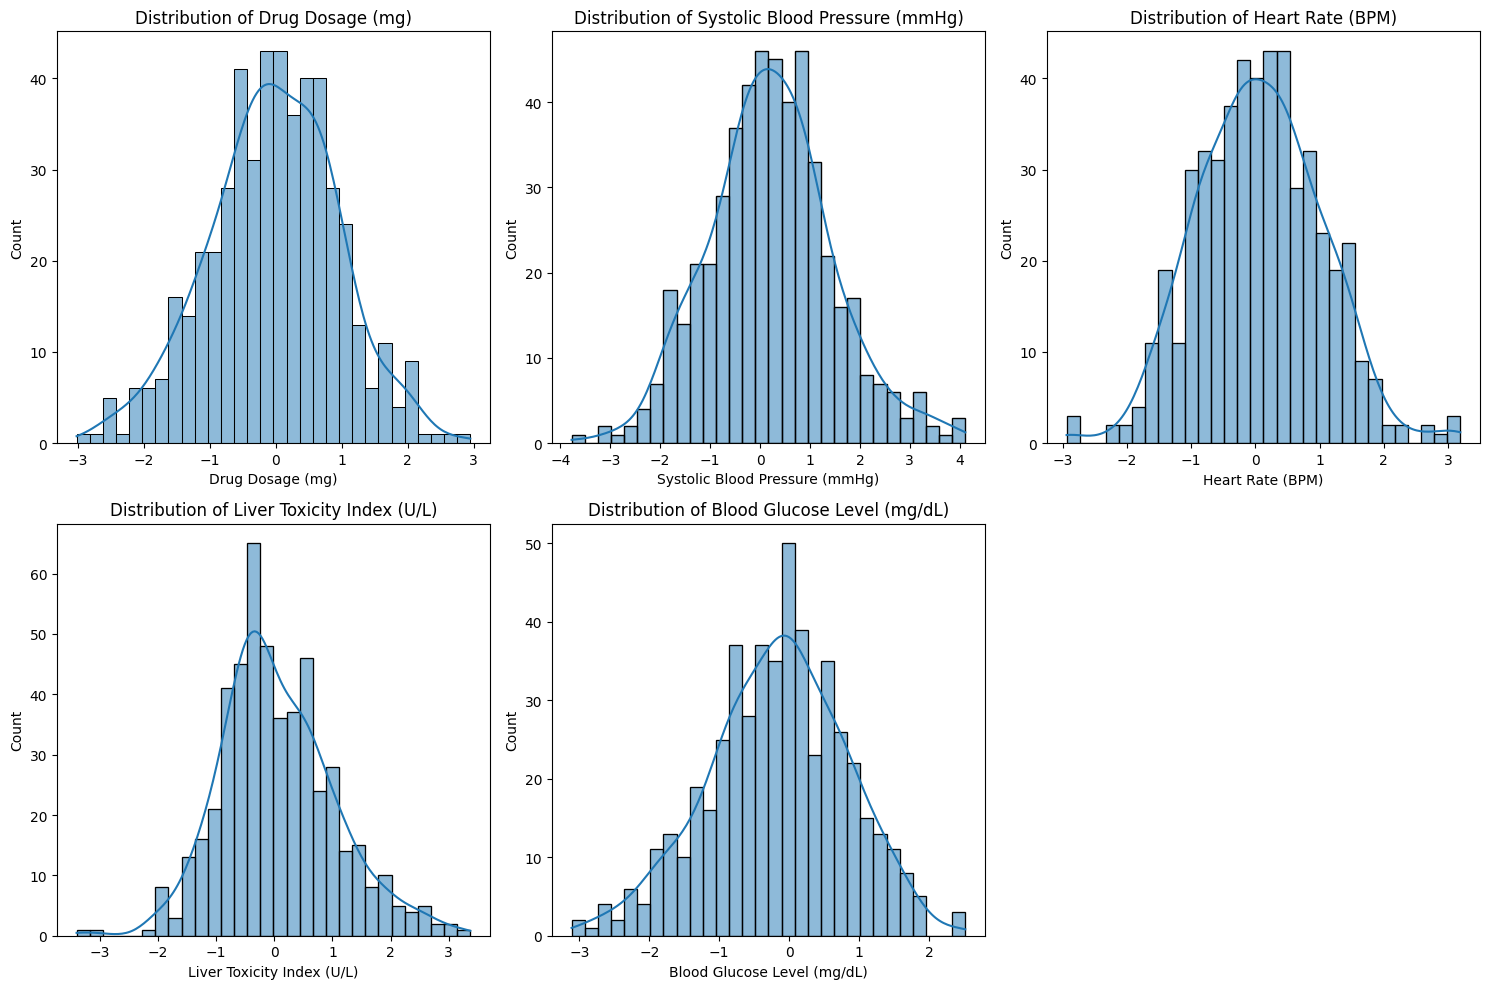

In [12]:
plt.figure(figsize=(15,10))
for i, feature in enumerate(features,1):
    plt.subplot(2,3,i)
    sns.histplot(df[feature],kde=True,bins=30)
    plt.title(f"Distribution of {feature}")
    plt.tight_layout()
plt.show()


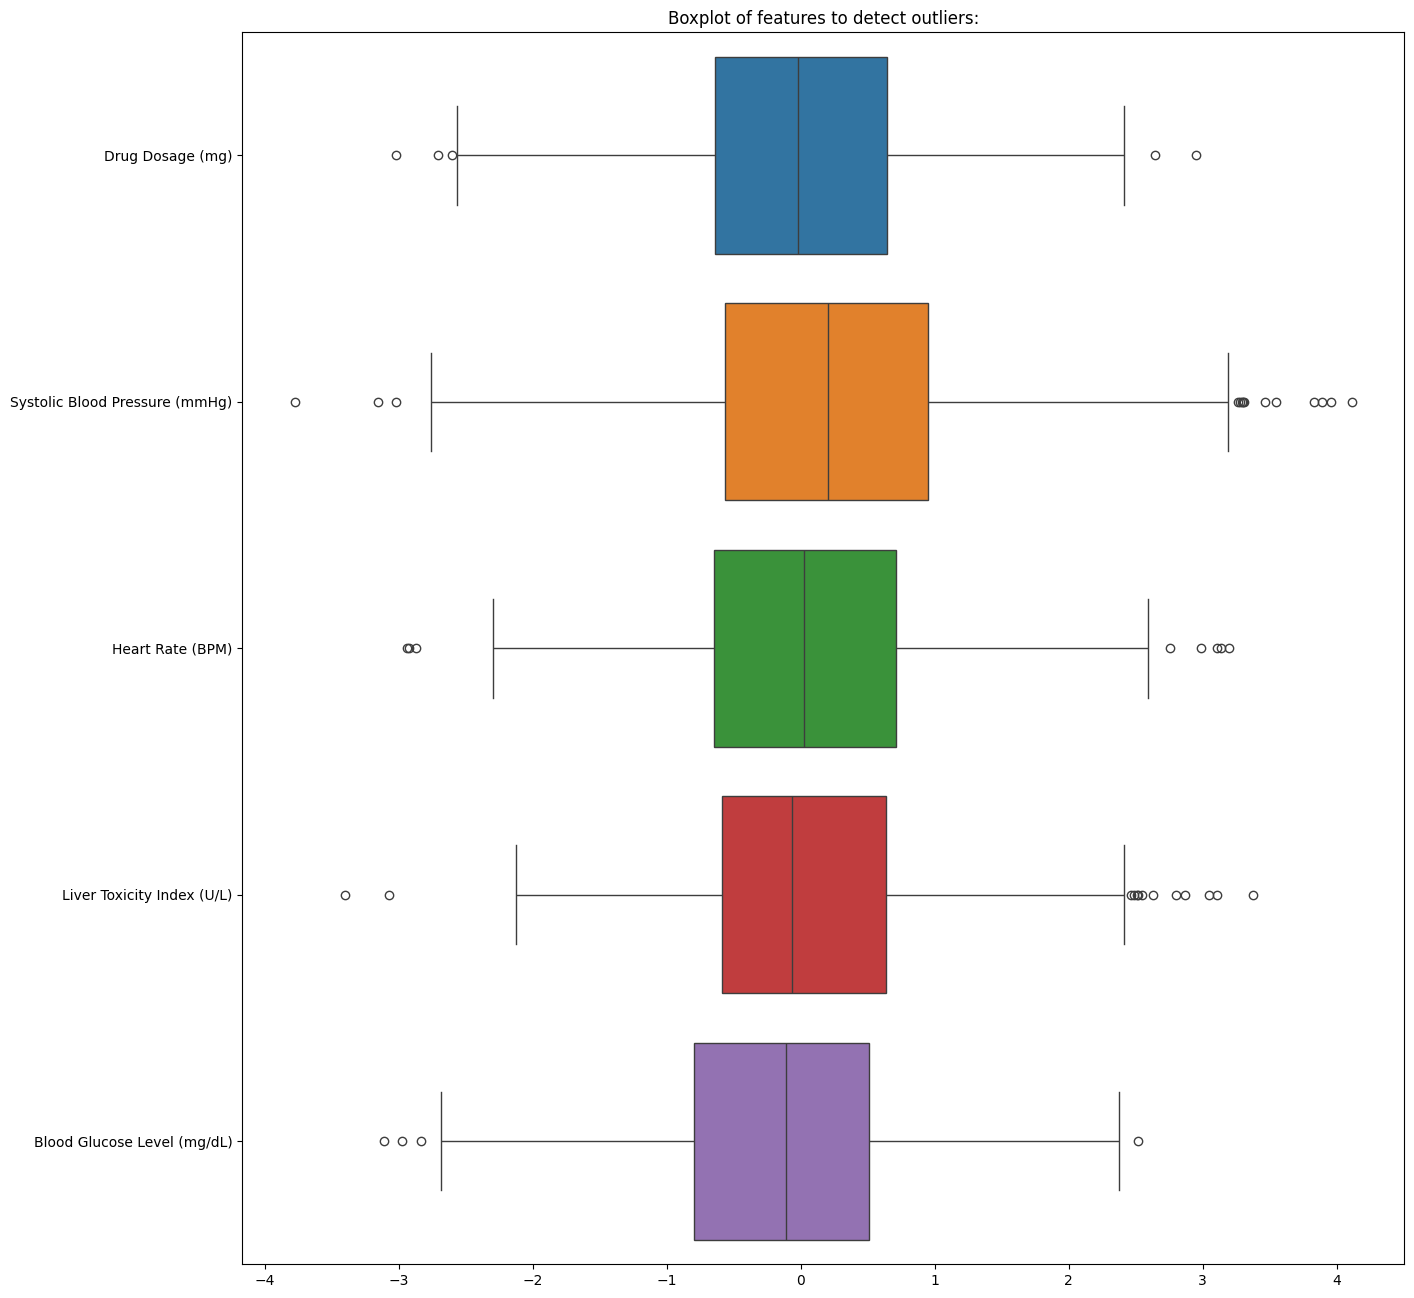

In [14]:
#Boxplot to detect outliers
plt.figure(figsize=(15,16))
sns.boxplot(data=df[features], orient="h")
plt.title("Boxplot of features to detect outliers:")
plt.show()

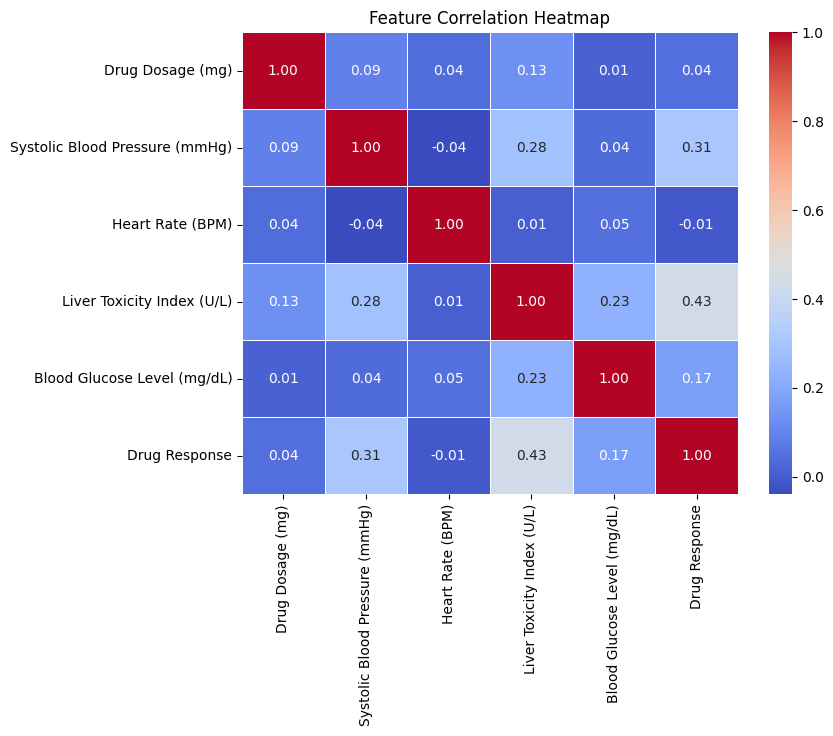

In [16]:
# To know feature correlations
plt.figure(figsize=(8,6))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix,annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


# Task 3 Data Visualization

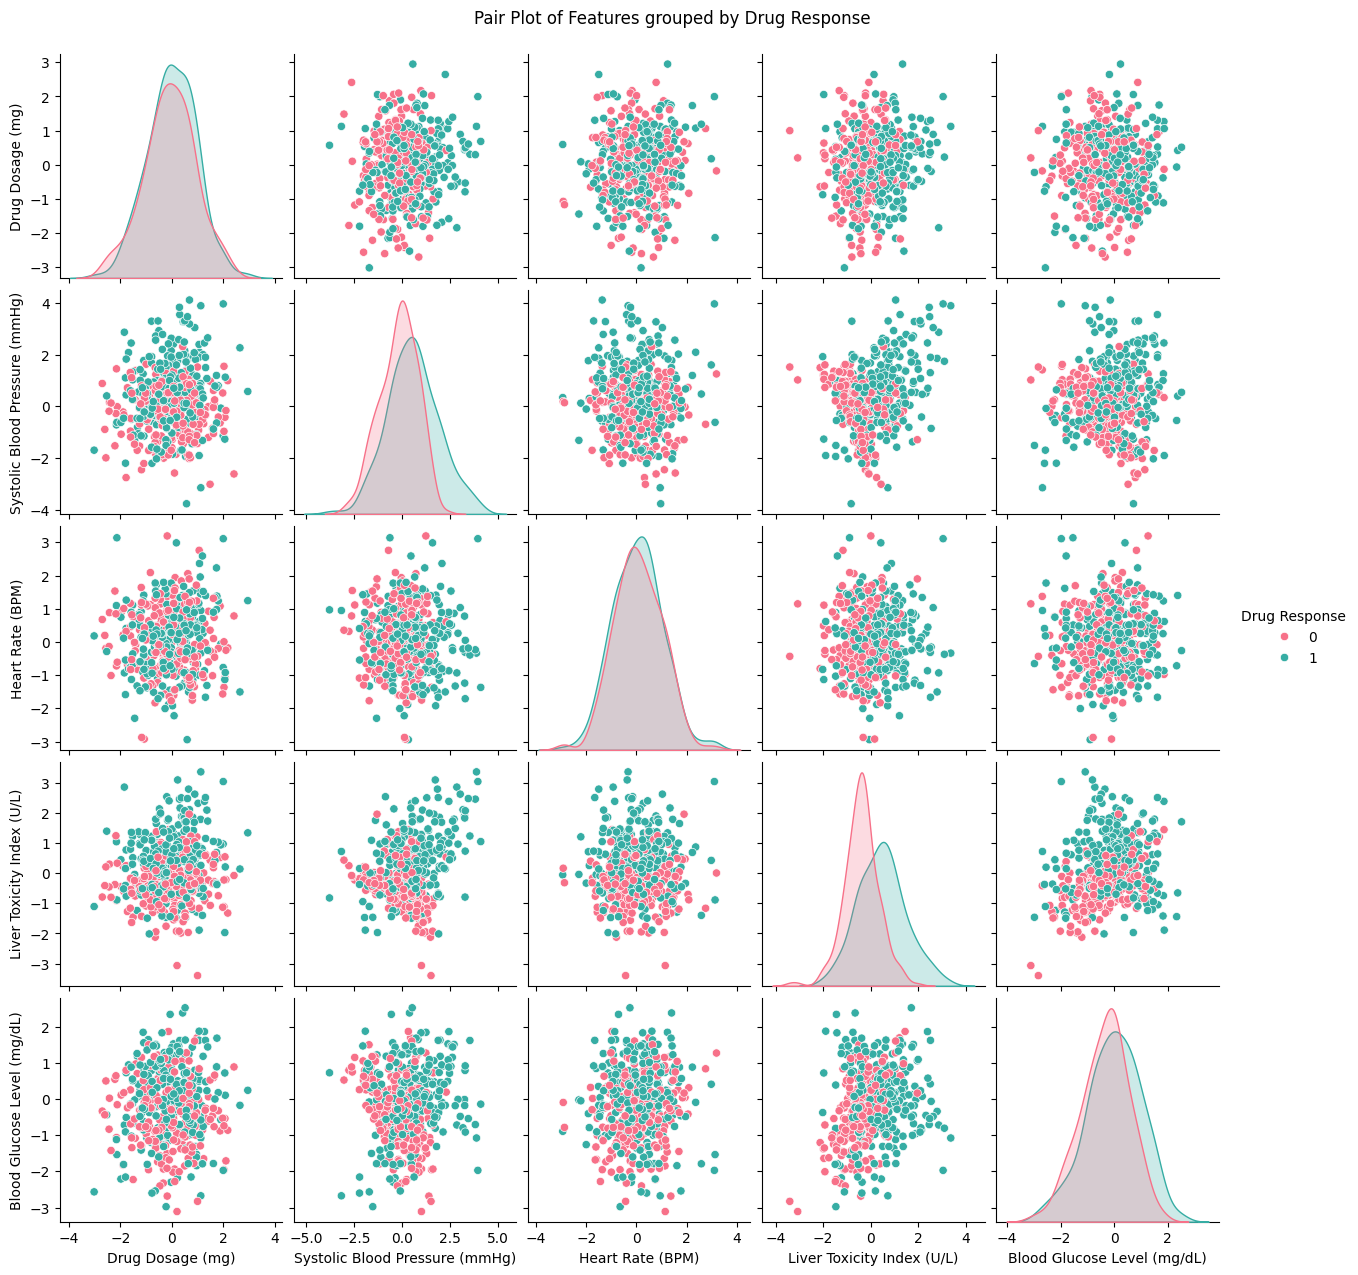

In [17]:
# Pair Plot for feature Relatioships
sns.pairplot(df, hue="Drug Response",palette="husl",diag_kind="kde")
plt.suptitle("Pair Plot of Features grouped by Drug Response",y=1.02)
plt.show()

/tmp/ipykernel_16918/1252853545.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Drug Response",data=df,palette="Set1")


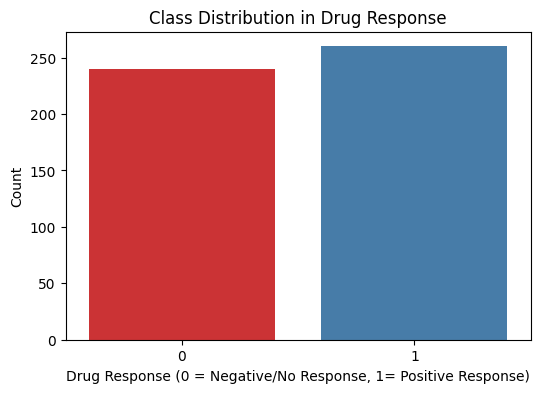

In [19]:
# Visualize Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Drug Response",data=df,palette="Set1")
plt.title("Class Distribution in Drug Response")
plt.xlabel("Drug Response (0 = Negative/No Response, 1= Positive Response)")
plt.ylabel("Count")
plt.show()

In [21]:
# Calculate Exact Balance
class_counts = df["Drug Response"].value_counts(normalize=True) * 100
print(f"Class Distribution:\n{class_counts}")

Class Distribution:
Drug Response
1    52.0
0    48.0
Name: proportion, dtype: float64


Task 2 Data Pre-Processing

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [25]:
# define features (X) & target (y)
X = df.drop("Drug Response",axis=1)
y = df["Drug Response"]

In [26]:
# split the dataset(80% training,20% testing)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [27]:
# standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Training Data Shape: {X_train_scaled.shape}")
print(f"Testing Data Shape: {X_test_scaled.shape}")

Training Data Shape: (400, 5)
Testing Data Shape: (100, 5)


# Task 4 SVM Implementation

In [29]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix

In [30]:
# to base line
svm_baseline = SVC(kernel="rbf",random_state=42)

In [32]:
# Train the model
svm_baseline.fit(X_train_scaled,y_train)
# Predict on testing data
y_pred_baseline = svm_baseline.predict(X_test_scaled)

In [33]:
# Evaluate Performance
print("Baseline Model Performance:")
print(f"Accuracy: {accuracy_score(y_test,y_pred_baseline):.4f}")
print(f"Precision: {precision_score(y_test,y_pred_baseline):.4f}")
print(f"Recall: {recall_score(y_test,y_pred_baseline):.4f}")
print(f"F1 Score: {f1_score(y_test,y_pred_baseline):.4f}\n")
print("Classification Report:\n",classification_report(y_test,y_pred_baseline))

Baseline Model Performance:
Accuracy: 0.7700
Precision: 0.7544
Recall: 0.8269
F1 Score: 0.7890

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.71      0.75        48
           1       0.75      0.83      0.79        52

    accuracy                           0.77       100
   macro avg       0.77      0.77      0.77       100
weighted avg       0.77      0.77      0.77       100



# Task 5 Visualization Of Results

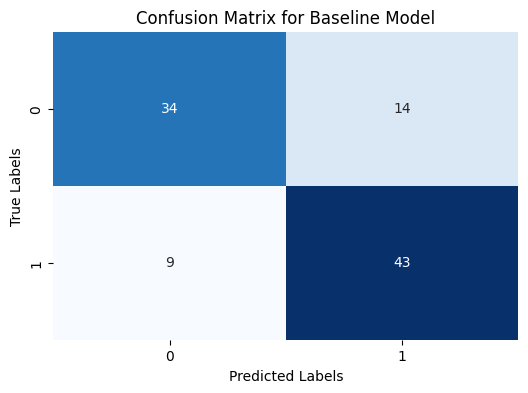

In [40]:
# Visualization
cm = confusion_matrix(y_test,y_pred_baseline)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",cbar=False)
plt.title("Confusion Matrix for Baseline Model")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Task 6 Parameter Tuning & optimization

In [41]:
from sklearn.model_selection import GridSearchCV

In [45]:
# define the parameter grid
param_grid = {
    "kernel":["linear","poly","rbf"],
    "C":[0.1,1,10,100],
    "gamma":["scale","auto",0.1,0.01,0.001]
}

In [46]:
param_grid

{'kernel': ['linear', 'poly', 'rbf'],
 'C': [0.1, 1, 10, 100],
 'gamma': ['scale', 'auto', 0.1, 0.01, 0.001]}

In [47]:
# Gridsearch CV
grid_search = GridSearchCV(SVC(random_state=42),param_grid,cv=5,scoring="accuracy",n_jobs=-1,verbose=1)
#fit grid search
grid_search.fit(X_train_scaled,y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


GridSearchCV(cv=5, estimator=SVC(random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
                         'kernel': ['linear', 'poly', 'rbf']},
             scoring='accuracy', verbose=1)

In [48]:
#Best parameters and estimator
print("Best Hyperparameters Found:",grid_search.best_params_)
best_svm = grid_search.best_estimator_


Best Hyperparameters Found: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}


In [49]:
# Evaluate
y_pred_optimised = best_svm.predict(X_test_scaled)
print("\n Optimised SVM Model Performance:")
print(classification_report(y_test,y_pred_optimised))


 Optimised SVM Model Performance:
              precision    recall  f1-score   support

           0       0.77      0.69      0.73        48
           1       0.74      0.81      0.77        52

    accuracy                           0.75       100
   macro avg       0.75      0.75      0.75       100
weighted avg       0.75      0.75      0.75       100



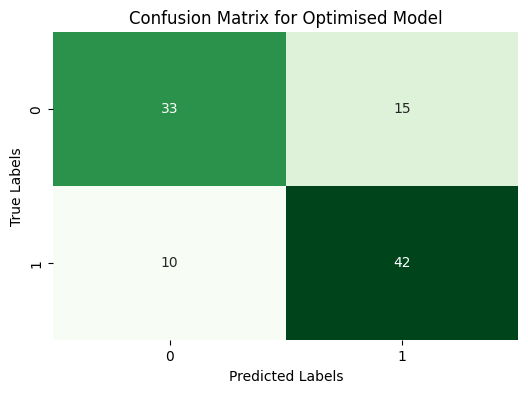

In [54]:
# visualize optimised confused matrix
cm_opt = confusion_matrix(y_test,y_pred_optimised)
plt.figure(figsize=(6,4))
sns.heatmap(cm_opt,annot=True,fmt="d",cmap="Greens",cbar=False)
plt.title("Confusion Matrix for Optimised Model")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Task 7 Comparision & Analysis

1. Comparison of SVM  models with various kernels  
*  During tuning process, we evaluated Linear,Polynomial, and Radial Basis  Function (RBF) kernels.  
    * Linear Kernel: Assume the data is linearly seperable.  
    * Polynomial Kernel: Captures interactions between features but can be expensive and prone to overfitting if degree is too high.  
    * RBF Kernel: Maps data into an infinte dimensional space to handle highly non-linear data.

2. SVM Strengths & Weakness  
* Strengths   
  * Handling High Dimentionality:If we decide we can later add more variables  
  * Robust to outliers  
* Weakness
  * Scaling sensitivity:The algorithm needs strict feature scaling ,without which features with larger numerical ranges would unfairly dominate the model.  

3. Practical implicaions of SVM in real-world classification tasks (Pharma Industry)
* Precision Medicine:Used to predict the perfect medicine required for a person based on their vitals , bloodline & past medications
* Risk Management: It reduces the risk taking any unknown medicine that may cause any huge suffer ,it can provide whether the possibility of medicine to work,such risky medicines can be avoided.